In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import torch
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoConfig,
                          AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.special import softmax
import matplotlib.pyplot as plt
import random
import shutil
import time
import os

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Seed Set!")

✅ Seed Set!


In [ ]:
train_df = pd.read_excel('/content/drive/MyDrive/our-thesis-dataset-4 (80-10-10) (for BERT)/train-thesis-4-80.xlsx')
val_df   = pd.read_excel('/content/drive/MyDrive/our-thesis-dataset-4 (80-10-10) (for BERT)/val-thesis-4-10.xlsx')
test_df  = pd.read_excel('/content/drive/MyDrive/our-thesis-dataset-4 (80-10-10) (for BERT)/test-thesis-4-10.xlsx')

id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

for df in [train_df, val_df, test_df]:
    df['label'] = df['sentiment'].map(label2id)

train_df = train_df[['text', 'label']]
val_df   = val_df[['text', 'label']]
test_df  = test_df[['text', 'label']]

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df),
    'validation': Dataset.from_pandas(val_df),
    'test': Dataset.from_pandas(test_df)
})

print("✅ Data Loaded!")
print(f"   Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

✅ Data Loaded!
   Train: 4800 | Val: 600 | Test: 600


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

print("✅ compute_metrics Ready!")

✅ compute_metrics Ready!


In [ ]:
def train_model(model_name, max_len, lr, epochs, batch_size):
    print(f"\n{'='*70}")
    print(f"🚀 Training: {model_name}")
    print(f"{'='*70}")

    set_seed(42)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(examples):
        return tokenizer(examples['text'], truncation=True,
                         padding='max_length', max_length=max_len)

    tokenized = dataset.map(tokenize_fn, batched=True)

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config
    )

    safe_name = model_name.replace("/", "_")

    args = TrainingArguments(
        output_dir=f"./{safe_name}-ckpt",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_steps=500,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,        # ← 10 epoch শেষে best model load করবে
        metric_for_best_model="eval_accuracy",
        greater_is_better=True,             # ← accuracy বেশি হলে ভালো, তাই True
        logging_dir=f"./logs-{safe_name}",
        logging_steps=50,
        seed=42,
        fp16=True,
        report_to="none"
        # ← EarlyStoppingCallback নেই
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        compute_metrics=compute_metrics
        # ← callbacks নেই
    )

    trainer.train()

    # ── Best Epoch Info ──
    log_history  = trainer.state.log_history
    best_val_acc = -1.0
    best_epoch   = 0
    best_val_loss = None

    for log in log_history:
        if 'eval_accuracy' in log:
            if log['eval_accuracy'] > best_val_acc:
                best_val_acc  = log['eval_accuracy']
                best_epoch    = int(log.get('epoch', 0))
                best_val_loss = log.get('eval_loss', None)

    print(f"\n   ✅ Best Epoch   : {best_epoch}")
    print(f"      Val Loss     : {best_val_loss:.4f}")
    print(f"      Val Accuracy : {best_val_acc*100:.2f}%")
    # if best_val_loss:
    #     print(f"      Val Loss     : {best_val_loss:.4f}")

    # ── Test Evaluation ──
    test_preds  = trainer.predict(tokenized['test'])
    true_labels = test_preds.label_ids
    pred_labels = np.argmax(test_preds.predictions, axis=-1)
    pred_probs  = softmax(test_preds.predictions, axis=-1)   # Soft Voting এর জন্য

    acc  = round(accuracy_score(true_labels, pred_labels) * 100, 2)
    prec = round(precision_score(true_labels, pred_labels, average='weighted') * 100, 2)
    rec  = round(recall_score(true_labels, pred_labels, average='weighted') * 100, 2)
    f1   = round(f1_score(true_labels, pred_labels, average='weighted') * 100, 2)

    print(f"\n📊 {model_name} — Test Results:")
    print(f"   Accuracy  : {acc}%")
    print(f"   Precision : {prec}%")
    print(f"   Recall    : {rec}%")
    print(f"   F1 Score  : {f1}%")

    # ── Checkpoint Delete ──
    ckpt_dir = f"./{safe_name}-ckpt"
    if os.path.exists(ckpt_dir):
        shutil.rmtree(ckpt_dir)
        print(f"🗑️  Checkpoint Deleted: {ckpt_dir}")

    return pred_labels, pred_probs, true_labels

print("✅ train_model() Ready!")

✅ train_model() Ready!


## Max Length 32

### Batch 16

In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 32,
    lr         = 1e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 7
      Val Loss     : 0.4504
      Val Accuracy : 91.33%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 90.33%
   Precision : 90.35%
   Recall    : 90.33%
   F1 Score  : 90.31%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
# ── XLM-R-Base ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 32,
    lr         = 2e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 10
      Val Loss     : 0.5588
      Val Accuracy : 91.00%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 90.67%
   Precision : 90.69%
   Recall    : 90.67%
   F1 Score  : 90.61%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


### Batch 8

In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 32,
    lr         = 2e-5,
    epochs     = 10,
    batch_size = 8
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 7
      Val Loss     : 0.5663
      Val Accuracy : 90.50%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 89.83%
   Precision : 89.84%
   Recall    : 89.83%
   F1 Score  : 89.79%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


## Max Length 64

### Batch 16

In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 1e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 6
      Val Loss     : 0.4125
      Val Accuracy : 91.33%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.17%
   Precision : 91.19%
   Recall    : 91.17%
   F1 Score  : 91.15%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 2e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 10
      Val Loss     : 0.4927
      Val Accuracy : 92.33%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 90.67%
   Precision : 90.67%
   Recall    : 90.67%
   F1 Score  : 90.64%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 3e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 7
      Val Loss     : 0.5785
      Val Accuracy : 90.83%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.5%
   Precision : 91.5%
   Recall    : 91.5%
   F1 Score  : 91.49%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


### Batch 8

In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 1e-5,
    epochs     = 10,
    batch_size = 8
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 9
      Val Loss     : 0.6393
      Val Accuracy : 90.67%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 90.5%
   Precision : 90.5%
   Recall    : 90.5%
   F1 Score  : 90.47%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 2e-5,
    epochs     = 10,
    batch_size = 8
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 8
      Val Loss     : 0.6034
      Val Accuracy : 91.83%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.33%
   Precision : 91.35%
   Recall    : 91.33%
   F1 Score  : 91.34%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
# ── XLM-RoBERTa ──
xlmr_preds, xlmr_probs, _ = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 3e-5,
    epochs     = 10,
    batch_size = 8
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 10
      Val Loss     : 0.7891
      Val Accuracy : 90.67%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.17%
   Precision : 91.19%
   Recall    : 91.17%
   F1 Score  : 91.13%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


### Best Model

---
model_name = "xlm-roberta-base", <br>
  max_len    = 64, <br>
  lr         = 3e-5, <br>
  epochs     = 10, <br>
  batch_size = 16 <br>

---
  ✅ Best Epoch   : 7 <br>
    Val Loss     : 0.5785 <br>
    Val Accuracy : 90.83%
---

  📊 xlm-roberta-base — Test Results: <br>
    Accuracy  : 91.5% <br>
    Precision : 91.5% <br>
    Recall    : 91.5% <br>
    F1 Score  : 91.49% <br>
---


In [ ]:
import torch
from transformers import TrainerCallback
from sklearn.metrics import accuracy_score
import numpy as np

class TrainAccuracyCallback(TrainerCallback):

    def __init__(self):
        self.trainer = None

    def set_trainer(self, trainer):
        self.trainer = trainer

    def on_epoch_end(self, args, state, control, **kwargs):

        if self.trainer is None:
            return

        model = self.trainer.model
        dataloader = self.trainer.get_train_dataloader()

        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in dataloader:

                batch = {k: v.to(model.device) for k, v in batch.items()}
                labels = batch.pop("labels")

                outputs = model(**batch)
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()

                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        train_acc = accuracy_score(all_labels, all_preds)

        print(f"📊 Epoch {int(state.epoch)} - Training Accuracy: {train_acc*100:.2f}%")

        self.trainer.log({"train_accuracy": train_acc})


print("TrainAccuracyCallback Function Loaded Successfully !!")

TrainAccuracyCallback Function Loaded Successfully !!


In [ ]:
model_name = "xlm-roberta-base"
max_len    = 64
lr         = 3e-5
epochs     = 10
batch_size = 16


print(f"\n{'='*70}")
print(f"🚀 Training: {model_name}")
print(f"{'='*70}")

set_seed(42)

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True,
                      padding='max_length', max_length=max_len)

tokenized = dataset.map(tokenize_fn, batched=True)

config = AutoConfig.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, config=config
)

safe_name = model_name.replace("/", "_")

args = TrainingArguments(
    output_dir=f"./{safe_name}-ckpt",
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=lr,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,        # ← 10 epoch শেষে best model load করবে
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,             # ← accuracy বেশি হলে ভালো, তাই True
    logging_dir=f"./logs-{safe_name}",
    logging_steps=50,
    seed=42,
    fp16=True,
    report_to="none"
    # ← EarlyStoppingCallback নেই
)

train_acc_callback = TrainAccuracyCallback()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    compute_metrics=compute_metrics,
    callbacks=[
        # EarlyStoppingCallback(early_stopping_patience=1),
        train_acc_callback
    ]
    # ← callbacks নেই
)

train_acc_callback.set_trainer(trainer)

trainer.train()

# ── Best Epoch Info ──
log_history  = trainer.state.log_history
best_val_acc = -1.0
best_epoch   = 0
best_val_loss = None

for log in log_history:
    if 'eval_accuracy' in log:
        if log['eval_accuracy'] > best_val_acc:
            best_val_acc  = log['eval_accuracy']
            best_epoch    = int(log.get('epoch', 0))
            best_val_loss = log.get('eval_loss', None)

print(f"\n   ✅ Best Epoch   : {best_epoch}")
print(f"      Val Loss     : {best_val_loss:.4f}")
print(f"      Val Accuracy : {best_val_acc*100:.2f}%")
# if best_val_loss:
#     print(f"      Val Loss     : {best_val_loss:.4f}")

# ── Test Evaluation ──
test_preds  = trainer.predict(tokenized['test'])
true_labels = test_preds.label_ids
pred_labels = np.argmax(test_preds.predictions, axis=-1)
pred_probs  = softmax(test_preds.predictions, axis=-1)   # Soft Voting এর জন্য

acc  = round(accuracy_score(true_labels, pred_labels) * 100, 2)
prec = round(precision_score(true_labels, pred_labels, average='weighted') * 100, 2)
rec  = round(recall_score(true_labels, pred_labels, average='weighted') * 100, 2)
f1   = round(f1_score(true_labels, pred_labels, average='weighted') * 100, 2)

print(f"\n📊 {model_name} — Test Results:")
print(f"   Accuracy  : {acc}%")
print(f"   Precision : {prec}%")
print(f"   Recall    : {rec}%")
print(f"   F1 Score  : {f1}%")

# ── Checkpoint Delete ──
ckpt_dir = f"./{safe_name}-ckpt"
if os.path.exists(ckpt_dir):
    shutil.rmtree(ckpt_dir)
    print(f"🗑️  Checkpoint Deleted: {ckpt_dir}")

    # return pred_labels, pred_probs, true_labels

print("✅ train_model() Ready!")


🚀 Training: xlm-roberta-base


Map:   0%|          | 0/4800 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

📊 Epoch 10 - Training Accuracy: 99.73%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


   ✅ Best Epoch   : 7
      Val Loss     : 0.5785
      Val Accuracy : 90.83%



📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.5%
   Precision : 91.5%
   Recall    : 91.5%
   F1 Score  : 91.49%
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt
✅ train_model() Ready!


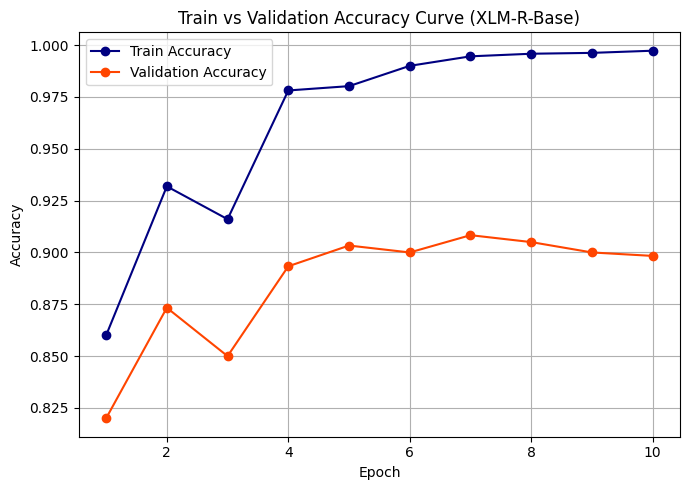

In [ ]:
train_acc = []
val_acc = []
epochs = []

for log in trainer.state.log_history:

    if 'train_accuracy' in log:
        train_acc.append(log['train_accuracy'])

    if 'eval_accuracy' in log:
        val_acc.append(log['eval_accuracy'])
        epochs.append(log['epoch'])

# Plot
plt.figure(figsize=(7,5))

plt.plot(epochs, train_acc[:len(epochs)], marker='o', label="Train Accuracy", color='navy')
plt.plot(epochs, val_acc, marker='o', label="Validation Accuracy", color='orangered')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy Curve (XLM-R-Base)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("XLM-R_train_val_accuracy_curve_new.png", dpi=300)

plt.show()

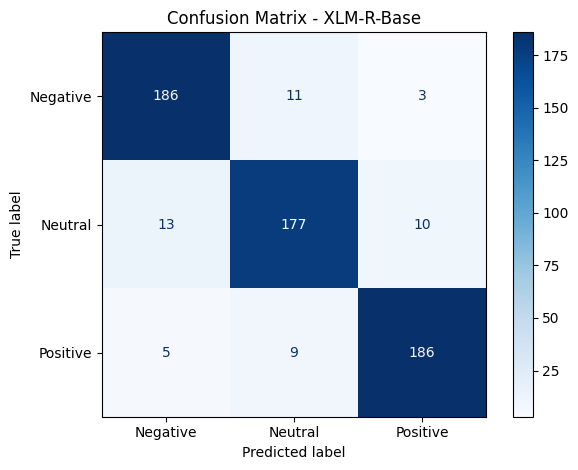

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    pred_labels,
    display_labels=['Negative','Neutral','Positive'],
    cmap='Blues'
)

plt.title("Confusion Matrix - XLM-R-Base")

plt.tight_layout()
plt.savefig("XLM-R_confusion_matrix_new.png", dpi=300)

plt.show()

In [ ]:
# ====================== CLASSIFICATION REPORT ======================
from sklearn.metrics import classification_report

print("\n" + "="*60)
print("Classification Report (XLM-R):")
print("="*60)

# Detailed classification report
report = classification_report(
    true_labels,
    pred_labels,
    target_names=['Negative', 'Neutral', 'Positive'],
    digits=2,
    output_dict=False
)

print(report)


Classification Report (XLM-R):
              precision    recall  f1-score   support

    Negative       0.91      0.93      0.92       200
     Neutral       0.90      0.89      0.89       200
    Positive       0.93      0.93      0.93       200

    accuracy                           0.92       600
   macro avg       0.91      0.92      0.91       600
weighted avg       0.91      0.92      0.91       600



## TIME - XLM-R-Base

In [ ]:
def get_folder_size_mb(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            filepath = os.path.join(dirpath, filename)
            if os.path.exists(filepath):
                total_size += os.path.getsize(filepath)
    return total_size / (1024 ** 2)


def train_model(model_name, max_len, lr, epochs, batch_size):
    print(f"\n{'='*70}")
    print(f"🚀 Training: {model_name}")
    print(f"{'='*70}")

    set_seed(42)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_fn(examples):
        return tokenizer(examples['text'], truncation=True,
                         padding='max_length', max_length=max_len)

    tokenized = dataset.map(tokenize_fn, batched=True)

    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, config=config
    )

    safe_name = model_name.replace("/", "_")

    args = TrainingArguments(
        output_dir=f"./{safe_name}-ckpt",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        warmup_steps=500,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,        # ← 10 epoch শেষে best model load করবে
        metric_for_best_model="eval_accuracy",
        greater_is_better=True,             # ← accuracy বেশি হলে ভালো, তাই True
        logging_dir=f"./logs-{safe_name}",
        logging_steps=50,
        seed=42,
        fp16=True,
        report_to="none"
        # ← EarlyStoppingCallback নেই
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized['train'],
        eval_dataset=tokenized['validation'],
        compute_metrics=compute_metrics
        # ← callbacks নেই
    )



    # ── Training Time & GPU Memory ──
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    train_start = time.time()

    trainer.train()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    train_end = time.time()

    training_time = train_end - train_start

    if torch.cuda.is_available():
        memory_usage = torch.cuda.max_memory_allocated() / (1024 ** 2)
    else:
        memory_usage = 0

    print(f"\n⏱️ Training Time: {training_time:.4f} seconds")
    print(f"🧠 Peak GPU Memory Usage: {memory_usage:.4f} MB")



    # ── Best Epoch Info ──
    log_history  = trainer.state.log_history
    best_val_acc = -1.0
    best_epoch   = 0
    best_val_loss = None

    for log in log_history:
        if 'eval_accuracy' in log:
            if log['eval_accuracy'] > best_val_acc:
                best_val_acc  = log['eval_accuracy']
                best_epoch    = int(log.get('epoch', 0))
                best_val_loss = log.get('eval_loss', None)

    print(f"\n   ✅ Best Epoch   : {best_epoch}")
    print(f"      Val Loss     : {best_val_loss:.4f}")
    print(f"      Val Accuracy : {best_val_acc*100:.2f}%")
    # if best_val_loss:
    #     print(f"      Val Loss     : {best_val_loss:.4f}")


    # ── Inference Time & Throughput ──
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    infer_start = time.time()

    test_preds = trainer.predict(tokenized['test'])

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    infer_end = time.time()

    total_inference_time = infer_end - infer_start
    num_test_samples = len(tokenized['test'])

    inference_time_ms = (total_inference_time / num_test_samples) * 1000
    throughput = num_test_samples / total_inference_time

    true_labels = test_preds.label_ids
    pred_labels = np.argmax(test_preds.predictions, axis=-1)
    pred_probs  = softmax(test_preds.predictions, axis=-1)

    print(f"\n⏱️ Total Inference Time: {total_inference_time:.4f} seconds")
    print(f"⚡ Inference Time: {inference_time_ms:.4f} ms/sample")
    print(f"🚀 Throughput: {throughput:.4f} samples/s")



    acc  = round(accuracy_score(true_labels, pred_labels) * 100, 2)
    prec = round(precision_score(true_labels, pred_labels, average='weighted') * 100, 2)
    rec  = round(recall_score(true_labels, pred_labels, average='weighted') * 100, 2)
    f1   = round(f1_score(true_labels, pred_labels, average='weighted') * 100, 2)

    print(f"\n📊 {model_name} — Test Results:")
    print(f"   Accuracy  : {acc}%")
    print(f"   Precision : {prec}%")
    print(f"   Recall    : {rec}%")
    print(f"   F1 Score  : {f1}%")



    # ── Model Size ──
    saved_model_dir = f"./{safe_name}-final-model"

    trainer.save_model(saved_model_dir)
    tokenizer.save_pretrained(saved_model_dir)

    model_size = get_folder_size_mb(saved_model_dir)

    print(f"💾 Model Size: {model_size:.4f} MB")


    complexity_result = {
        "Training Time (s)": round(training_time, 4),
        "Inference Time (ms/sample)": round(inference_time_ms, 4),
        "Throughput (samples/s)": round(throughput, 4),
        "Memory Usage (MB)": round(memory_usage, 4),
        "Model Size (MB)": round(model_size, 4)
    }

    complexity_df = pd.DataFrame(
        [complexity_result],
        index=[model_name]
    )

    print("\nComputational Complexity Result:")
    print(complexity_df)


    # ── Checkpoint Delete ──
    ckpt_dir = f"./{safe_name}-ckpt"
    if os.path.exists(ckpt_dir):
        shutil.rmtree(ckpt_dir)
        print(f"🗑️  Checkpoint Deleted: {ckpt_dir}")

    return pred_labels, pred_probs, true_labels, complexity_result

print("✅ train_model() Ready!")

✅ train_model() Ready!


In [ ]:
# ── XLM-R-Base ──
xlmr_preds, xlmr_probs, true_labels, xlmr_complexity = train_model(
    model_name = "xlm-roberta-base",
    max_len    = 64,
    lr         = 3e-5,
    epochs     = 10,
    batch_size = 16
)


🚀 Training: xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


⏱️ Training Time: 1784.6789 seconds
🧠 Peak GPU Memory Usage: 4290.9668 MB

   ✅ Best Epoch   : 7
      Val Loss     : 0.5785
      Val Accuracy : 90.83%



⏱️ Total Inference Time: 0.7645 seconds
⚡ Inference Time: 1.2741 ms/sample
🚀 Throughput: 784.8713 samples/s

📊 xlm-roberta-base — Test Results:
   Accuracy  : 91.5%
   Precision : 91.5%
   Recall    : 91.5%
   F1 Score  : 91.49%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model Size: 1076.6948 MB

Computational Complexity Result:
                  Training Time (s)  Inference Time (ms/sample)  \
xlm-roberta-base          1784.6789                      1.2741   

                  Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
xlm-roberta-base                784.8713          4290.9668        1076.6948  
🗑️  Checkpoint Deleted: ./xlm-roberta-base-ckpt


In [ ]:
xlmr_complexity_df = pd.DataFrame(
    [xlmr_complexity],
    index=["XLM-R-Base"]
)

print("\nXLM-R-Base Computational Complexity Result:")
print(xlmr_complexity_df)


XLM-R-Base Computational Complexity Result:
            Training Time (s)  Inference Time (ms/sample)  \
XLM-R-Base          1784.6789                      1.2741   

            Throughput (samples/s)  Memory Usage (MB)  Model Size (MB)  
XLM-R-Base                784.8713          4290.9668        1076.6948  
